In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf

# configuracion del tamaño de los graficos
plt.rcParams['figure.figsize'] = (8, 5)

In [5]:
# cargar el dataset
datos = pd.read_excel('Dataset/Peso y Consumo.xlsx')
datos = datos.drop('No', axis=1)
datos.columns = ['Peso', 'Consumo']
datos.head()

,Peso,Consumo
0,981,11
1,878,12
2,708,8
3,1138,11
4,1064,13


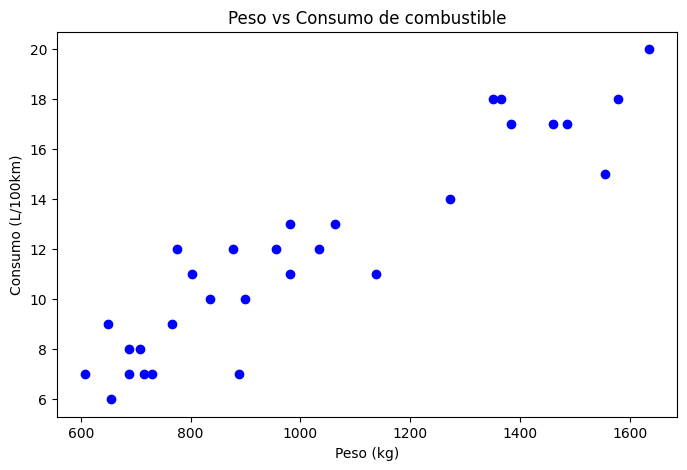

In [ ]:
# grafico de dispersion
# se onserva la relacion existente entre las variables
plt.xlabel('Peso (kg)')
plt.ylabel('Consumo (L/100km)')
plt.title('Peso vs Consumo de combustible')
plt.scatter(datos['Peso'], datos['Consumo'], color='blue');

In [13]:
# calculamos la correlacion entre las variables
datos.corr().style.highlight_max(color='green')

,Peso,Consumo
Peso,1.000000,0.928509
Consumo,0.928509,1.000000


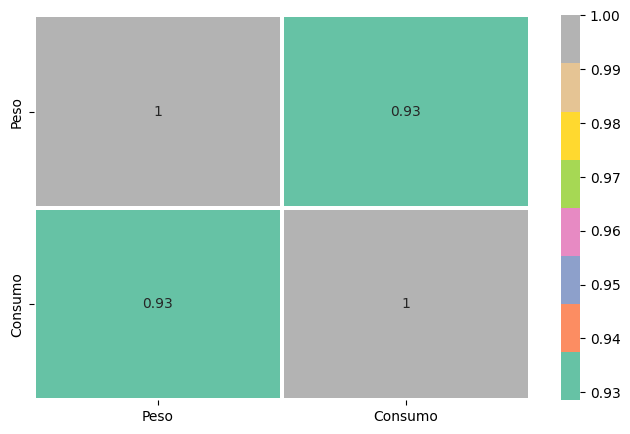

In [15]:
sns.heatmap(datos.corr(), annot=True, fmt='.2g', linewidths=1.5, cmap= 'Set2');

Ajuste polinomico - overfitting

Exactitud del modelo (R^2): 86.21%


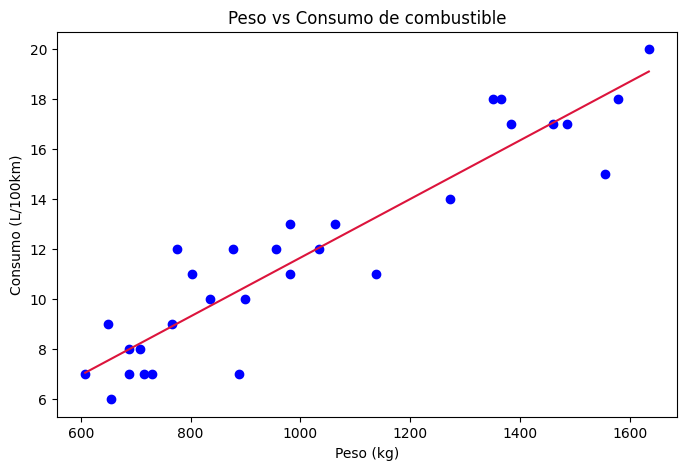

In [19]:
x=datos.Peso.values
y=datos.Consumo.values
modelo = np.poly1d(np.polyfit(x, y, 1)) # grado de ajuste polinomio
linea = np.linspace(min(x), max(x)) # escala para x
plt.scatter(x, y, color='blue')
plt.plot(linea, modelo(linea), color='crimson') # grafico de la linea de regresion
plt.xlabel('Peso (kg)')
plt.ylabel('Consumo (L/100km)')
plt.title('Peso vs Consumo de combustible')
r2 = r2_score(y, modelo(x))
print(f'Exactitud del modelo (R^2): {r2:.2%}')

linear Regresion

In [32]:
# separamos variables independientes y dependientes
x = datos[['Peso']]
y = datos['Consumo']

# modelo de regresion lineal

regresion = LinearRegression()
regresion.fit(x, y)
y_pred = regresion.predict(x)

# colocamos los resultados del modelo
print(f'Intercepto: {regresion.intercept_:.4f}')
coeficiente = regresion.coef_.flatten()[0] 
print(f'Coeficiente de {x.columns[0]} = {coeficiente:.4f}')
print(f'Score: {regresion.score(x, y):.2%}')

Intercepto: -0.0713
Coeficiente de Peso = 0.0117
Score: 86.21%


$$\Large \color {blue} Consumo = {regresion.intercept_:.4f} + {coeficiente:.4f} \cdot Peso$$

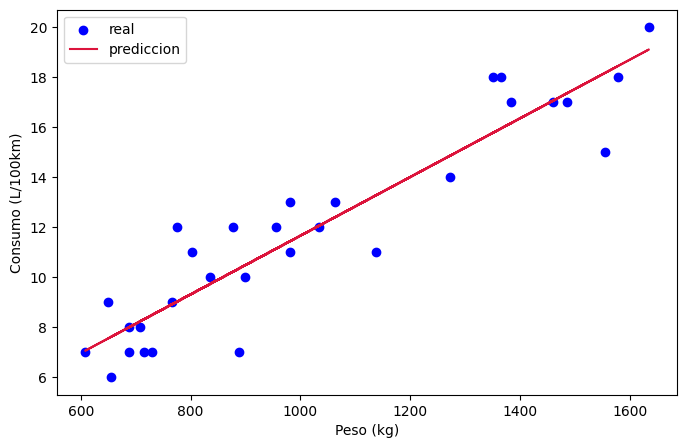

In [22]:
plt.scatter(x, y, color='blue', label = 'real')
plt.plot(x, y_pred, color='crimson', label ='prediccion')
plt.xlabel('Peso (kg)')
plt.ylabel('Consumo (L/100km)')
plt.legend()

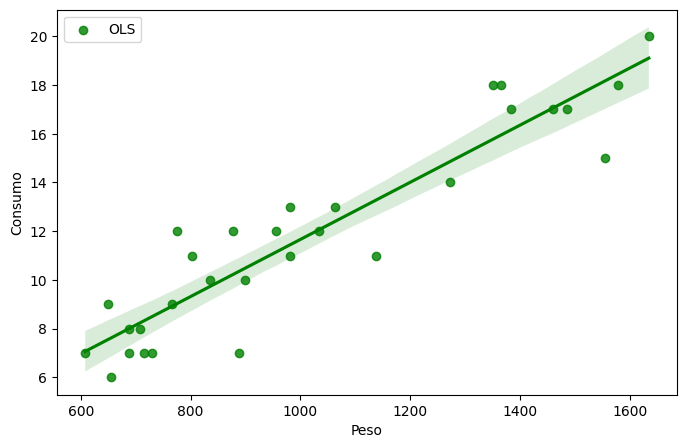

In [25]:
sns.regplot(data=datos, x='Peso', y='Consumo', color='green', scatter=True, label = 'OLS');
plt.legend()

Grafiquemos el error - residuo

Error cuadratico medio: 2.2219


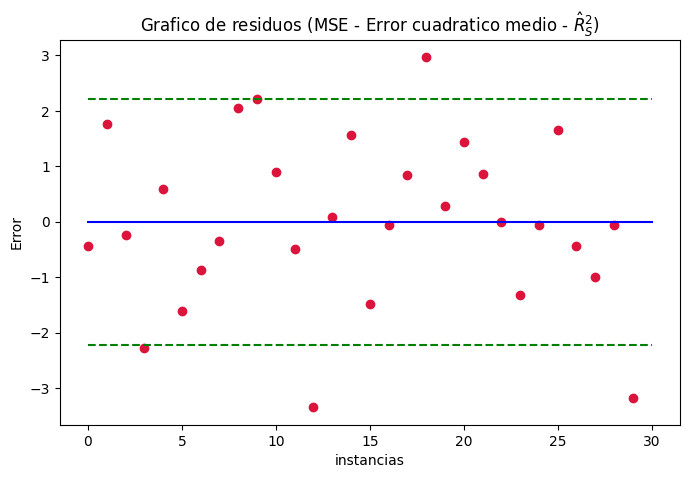

In [31]:
x1 = np.arange(len(y_pred))
plt.scatter(x1, (y - y_pred), color='crimson')
R2s = mean_squared_error(y, y_pred)
print(f'Error cuadratico medio: {R2s:.4f}')
plt.plot([0, len(y_pred)], [R2s, R2s], color='green', ls= '--')
plt.plot([0, len(y_pred)], [-R2s, -R2s], color='green', ls= '--')
plt.plot([0, len(y_pred)], [0, 0], 'b-')
plt.title('Grafico de residuos (MSE - Error cuadratico medio - $\\hat R^2_S$)')
plt.xlabel('instancias')
plt.ylabel('Error');

Separamos en datos para entrenamiento y prueba

In [34]:
x = datos[['Peso']]
y = datos['Consumo']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
regresion = LinearRegression()
regresion.fit(x_train, y_train)
y_pred = regresion.predict(x_test)

print(f'Intercepto: {regresion.intercept_:.4f}')
coeficiente = regresion.coef_.flatten()[0] 
print(f'Coeficiente de {x.columns[0]} = {coeficiente:.4f}')
print(f'Score: {regresion.score(x_train, y_train):.2%}')


Intercepto: 0.1175
Coeficiente de Peso = 0.0115
Score: 78.44%


OLS - minimos cuadrados ordinarios

In [ ]:
datos_train =  x_train.join(y_train)
regresion1 = smf.ols(formula='Consumo ~ Peso', data=datos_train)
regresion1 = regresion1.fit()
regresion1.summary()
# si el p > es mayor a 0.5 esa variable no nos sirve 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Consumo   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     80.05
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           8.77e-09
Time:                        08:55:08   Log-Likelihood:                -46.107
No. Observations:                  24   AIC:                             96.21
Df Residuals:                      22   BIC:                             98.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1175      1.325      0.089      0.930      -2.629       2.864
Peso           0.0115      0.001      8.947      0.000       0.009       0.014
==============================================================================
Omnibus:                        0.678   Durbin-Watson:                   1.772
Prob(Omnibus):                  0.712   Jarque-Bera (JB):                0.729
Skew:                          -0.236   Prob(JB):                        0.694
Kurtosis:                       2.288   Cond. No.                     3.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [36]:
regresion1.params

Intercept    0.117527
Peso         0.011533
dtype: float64